In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
df.head()

/tmp/ipykernel_9206/2479130355.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267921,72.306491,70.568495,70.819193,118387200
2020-01-07,71.928032,72.533072,71.708672,72.277555,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


In [3]:
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]
df = df.dropna()

In [4]:
df['Target'] = df['Close'].shift(-1)
df = df.dropna()

In [5]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [8]:
predictions = model.predict(X_test)

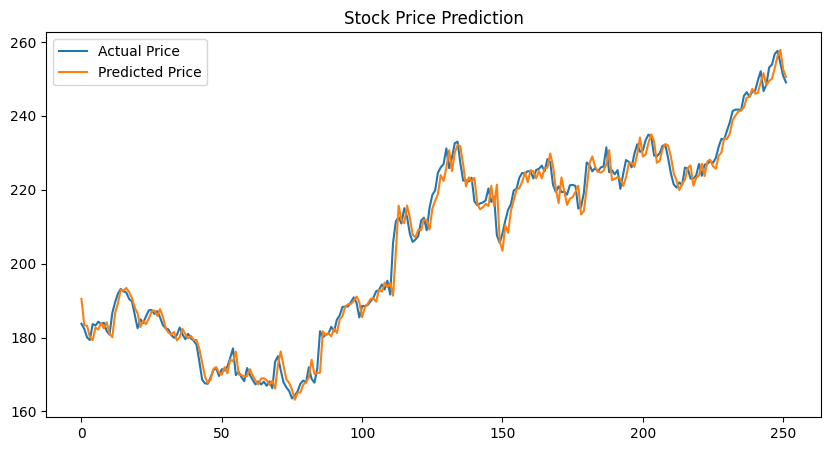

In [9]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Stock Price Prediction")
plt.show()